<a href="https://colab.research.google.com/github/gowripreetham/SJSU_Deep_Learning_neural-network-using-numpy-keras-pytorch/blob/main/colab_b_pytorch_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab B — 3-Layer Neural Network: PyTorch from Scratch

**Assignment:** Build a 3-layer deep neural network using **raw PyTorch tensors only** — no `nn.Module`, no `nn.Linear`, no optimizer classes.  
Manual weight tensors with `requires_grad=True` + manual gradient zeroing.

---

## Architecture: 3 → 64 → 32 → 1
- All weights are plain `torch.Tensor` with autograd enabled
- No PyTorch builtin layer functionality
- Same 3-variable nonlinear regression problem as Colab A

In [1]:
# ─────────────────────────────────────────────
# SECTION 1: Imports
# ─────────────────────────────────────────────
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {DEVICE}')

PyTorch version : 2.10.0+cpu
Device          : cpu


## Section 2: Synthetic Data

Same equation as Colab A:  `y = sin(x1)*cos(x2) + x3² + 0.5*sin(x1*x3) + ε`

In [2]:
# ─────────────────────────────────────────────
# SECTION 2: Synthetic Data
# ─────────────────────────────────────────────

def generate_data(n=2000):
    x1 = np.random.uniform(-np.pi, np.pi, n)
    x2 = np.random.uniform(-np.pi, np.pi, n)
    x3 = np.random.uniform(-2, 2, n)
    noise = np.random.normal(0, 0.05, n)
    y = np.sin(x1)*np.cos(x2) + x3**2 + 0.5*np.sin(x1*x3) + noise
    X = np.stack([x1, x2, x3], axis=1).astype(np.float32)
    y = y.reshape(-1, 1).astype(np.float32)
    return X, y

X_np, y_np = generate_data()

# Normalize
X_mean, X_std = X_np.mean(0), X_np.std(0)
y_mean, y_std = y_np.mean(), y_np.std()
X_np = (X_np - X_mean) / X_std
y_np = (y_np - y_mean) / y_std

# Split
split = int(0.8 * len(X_np))
X_tr, X_te = X_np[:split], X_np[split:]
y_tr, y_te = y_np[:split], y_np[split:]

# Convert to tensors (no gradient on data)
X_train = torch.from_numpy(X_tr).to(DEVICE)
y_train = torch.from_numpy(y_tr).to(DEVICE)
X_test  = torch.from_numpy(X_te).to(DEVICE)
y_test  = torch.from_numpy(y_te).to(DEVICE)

print(f'Train: {X_train.shape} → {y_train.shape}')
print(f'Test : {X_test.shape}  → {y_test.shape}')

Train: torch.Size([1600, 3]) → torch.Size([1600, 1])
Test : torch.Size([400, 3])  → torch.Size([400, 1])


## Section 3: Manual Weight Initialization

We create **raw tensors** with `requires_grad=True`.  
This tells PyTorch to track gradients for these tensors during `.backward()`.  
**No nn.Module, no nn.Linear, no nn.Parameter.**

In [3]:
# ─────────────────────────────────────────────
# SECTION 3: Raw Tensor Weights (from scratch)
# ─────────────────────────────────────────────

def init_weights_scratch():
    """Initialize all weights as plain tensors with autograd enabled.

    requires_grad=True means PyTorch will:
      - Build a computational graph during forward pass
      - Compute .grad during .backward()

    This is DIFFERENT from nn.Module which wraps these into nn.Parameter.
    Here we manually manage everything.
    """
    def he(fan_in, fan_out):
        """He initialization: scale = sqrt(2 / fan_in)"""
        return torch.randn(fan_in, fan_out) * (2.0 / fan_in) ** 0.5

    # Layer 1: 3 → 64
    W1 = he(3, 64).to(DEVICE).requires_grad_(True)
    b1 = torch.zeros(1, 64).to(DEVICE).requires_grad_(True)

    # Layer 2: 64 → 32
    W2 = he(64, 32).to(DEVICE).requires_grad_(True)
    b2 = torch.zeros(1, 32).to(DEVICE).requires_grad_(True)

    # Layer 3: 32 → 1
    W3 = he(32, 1).to(DEVICE).requires_grad_(True)
    b3 = torch.zeros(1, 1).to(DEVICE).requires_grad_(True)

    weights = [W1, b1, W2, b2, W3, b3]
    names   = ['W1', 'b1', 'W2', 'b2', 'W3', 'b3']

    for name, w in zip(names, weights):
        print(f'{name}: shape={w.shape}, requires_grad={w.requires_grad}')

    return weights

weights = init_weights_scratch()
W1, b1, W2, b2, W3, b3 = weights
total = sum(w.numel() for w in weights)
print(f'\nTotal parameters: {total}')

W1: shape=torch.Size([3, 64]), requires_grad=True
b1: shape=torch.Size([1, 64]), requires_grad=True
W2: shape=torch.Size([64, 32]), requires_grad=True
b2: shape=torch.Size([1, 32]), requires_grad=True
W3: shape=torch.Size([32, 1]), requires_grad=True
b3: shape=torch.Size([1, 1]), requires_grad=True

Total parameters: 2369


## Section 4: Forward Pass

We use plain tensor operations: `@` (matmul) or `torch.mm`.  
PyTorch **automatically builds the computation graph** as we run these operations.

In [4]:
# ─────────────────────────────────────────────
# SECTION 4: Forward Pass (raw tensor ops)
# ─────────────────────────────────────────────

def forward_scratch(X, W1, b1, W2, b2, W3, b3):
    """3-layer forward pass using raw tensor math.

    We use torch.mm (matrix multiply) and torch.relu.
    NO nn.Linear, NO nn.Module.

    PyTorch silently builds the computation graph here,
    enabling .backward() later.
    """
    # Layer 1: Z1 = X @ W1 + b1,  A1 = relu(Z1)
    Z1 = torch.mm(X, W1) + b1          # (batch, 64)
    A1 = torch.relu(Z1)                # ReLU activation

    # Layer 2: Z2 = A1 @ W2 + b2,  A2 = relu(Z2)
    Z2 = torch.mm(A1, W2) + b2         # (batch, 32)
    A2 = torch.relu(Z2)                # ReLU activation

    # Layer 3: Z3 = A2 @ W3 + b3,  A3 = Z3 (linear output)
    Z3 = torch.mm(A2, W3) + b3         # (batch, 1)
    A3 = Z3                            # Linear: no activation for regression

    return A3

# Test forward pass
with torch.no_grad():
    test_out = forward_scratch(X_train[:5], W1, b1, W2, b2, W3, b3)
    print('Forward pass output (5 samples):')
    print(test_out)

Forward pass output (5 samples):
tensor([[-0.2969],
        [-1.3546],
        [-1.4155],
        [ 0.2205],
        [ 0.6854]])


## Section 5: Training Loop

Key pattern for PyTorch **from scratch**:
1. `y_pred = forward(X, ...)` — forward pass builds computation graph
2. `loss = mse(y_pred, y)` — attach loss to graph
3. `loss.backward()` — PyTorch auto-differentiates back through graph
4. `with torch.no_grad(): W -= lr * W.grad` — manual SGD update
5. `W.grad.zero_()` — **must manually zero gradients** (they accumulate by default)

In [5]:
# ─────────────────────────────────────────────
# SECTION 5: Training Loop (manual SGD)
# ─────────────────────────────────────────────

# Re-initialize fresh weights
weights = init_weights_scratch()
W1, b1, W2, b2, W3, b3 = weights

LR         = 0.005
EPOCHS     = 500
BATCH_SIZE = 64
n          = X_train.shape[0]

train_losses = []
test_losses  = []

print(f'{'Epoch':>8}  {'Train Loss':>12}  {'Test Loss':>12}')
print('-' * 38)

for epoch in range(1, EPOCHS + 1):

    # ── Shuffle data each epoch ───────────────
    perm = torch.randperm(n)
    X_shuf = X_train[perm]
    y_shuf = y_train[perm]

    epoch_loss = 0.0
    n_batches  = 0

    for start in range(0, n, BATCH_SIZE):
        Xb = X_shuf[start : start + BATCH_SIZE]
        yb = y_shuf[start : start + BATCH_SIZE]

        # ── Forward pass ─────────────────────
        y_pred = forward_scratch(Xb, W1, b1, W2, b2, W3, b3)

        # ── Loss (MSE) ────────────────────────
        loss = ((y_pred - yb) ** 2).mean()
        epoch_loss += loss.item()
        n_batches  += 1

        # ── Backward pass ────────────────────
        # loss.backward() computes .grad for all tensors
        # in the graph that have requires_grad=True
        loss.backward()

        # ── Manual weight update (SGD) ────────
        # Must wrap in no_grad so the update ops
        # don't get added to the computation graph
        with torch.no_grad():
            for w in [W1, b1, W2, b2, W3, b3]:
                w -= LR * w.grad
                w.grad.zero_()   # MUST zero grads manually — PyTorch accumulates!

    # ── Epoch evaluation ──────────────────────
    with torch.no_grad():
        tr_loss = epoch_loss / n_batches
        te_pred = forward_scratch(X_test, W1, b1, W2, b2, W3, b3)
        te_loss = ((te_pred - y_test) ** 2).mean().item()

    train_losses.append(tr_loss)
    test_losses.append(te_loss)

    if epoch % 50 == 0 or epoch == 1:
        print(f'{epoch:>8}  {tr_loss:>12.6f}  {te_loss:>12.6f}')

print('-' * 38)
print(f'Final train: {train_losses[-1]:.6f}  |  Final test: {test_losses[-1]:.6f}')

W1: shape=torch.Size([3, 64]), requires_grad=True
b1: shape=torch.Size([1, 64]), requires_grad=True
W2: shape=torch.Size([64, 32]), requires_grad=True
b2: shape=torch.Size([1, 32]), requires_grad=True
W3: shape=torch.Size([32, 1]), requires_grad=True
b3: shape=torch.Size([1, 1]), requires_grad=True
   Epoch    Train Loss     Test Loss
--------------------------------------
       1      1.038855      0.743982
      50      0.101911      0.110570
     100      0.068729      0.078445
     150      0.052587      0.063562
     200      0.041936      0.055858
     250      0.034733      0.047090
     300      0.029323      0.045607
     350      0.026425      0.039484
     400      0.024036      0.036532
     450      0.022544      0.035278
     500      0.021307      0.032816
--------------------------------------
Final train: 0.021307  |  Final test: 0.032816


## Section 6: Results

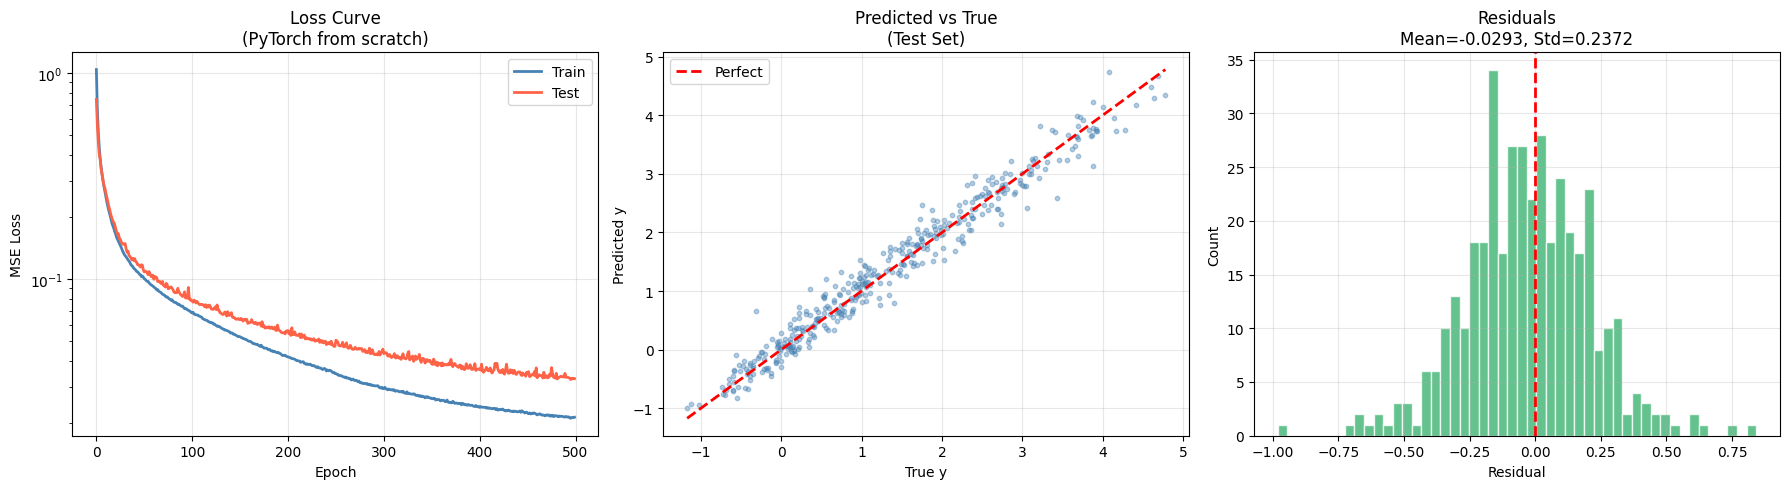

FINAL TEST METRICS (Colab B - PyTorch Scratch)
R² Score : 0.9667
MAE      : 0.1860
RMSE     : 0.2390


In [6]:
# ─────────────────────────────────────────────
# SECTION 6: Results & Visualization
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axes[0].plot(train_losses, label='Train', color='steelblue', lw=2)
axes[0].plot(test_losses,  label='Test',  color='tomato',    lw=2)
axes[0].set_yscale('log')
axes[0].set_title('Loss Curve\n(PyTorch from scratch)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Predicted vs Actual
with torch.no_grad():
    y_pred_np = forward_scratch(X_test, W1, b1, W2, b2, W3, b3).cpu().numpy()

y_true_denorm = y_te * y_std + y_mean
y_pred_denorm = y_pred_np * y_std + y_mean

axes[1].scatter(y_true_denorm, y_pred_denorm, alpha=0.4, s=10, color='steelblue')
lims = [y_true_denorm.min(), y_true_denorm.max()]
axes[1].plot(lims, lims, 'r--', lw=2, label='Perfect')
axes[1].set_title('Predicted vs True\n(Test Set)')
axes[1].set_xlabel('True y'); axes[1].set_ylabel('Predicted y')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Residuals
resid = (y_true_denorm - y_pred_denorm).ravel()
axes[2].hist(resid, bins=50, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', lw=2)
axes[2].set_title(f'Residuals\nMean={resid.mean():.4f}, Std={resid.std():.4f}')
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Count')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('colab_b_results.png', dpi=120, bbox_inches='tight')
plt.show()

r2  = r2_score(y_true_denorm, y_pred_denorm)
mae = mean_absolute_error(y_true_denorm, y_pred_denorm)
mse_val = np.mean(resid**2)
print('=' * 45)
print('FINAL TEST METRICS (Colab B - PyTorch Scratch)')
print('=' * 45)
print(f'R² Score : {r2:.4f}')
print(f'MAE      : {mae:.4f}')
print(f'RMSE     : {np.sqrt(mse_val):.4f}')
print('=' * 45)